In [2]:
import pandas as pd

df = pd.read_csv("/content/credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [6]:
df.dtypes

,0
transaction_id,int64
amount,float64
transaction_hour,int64
merchant_category,object
foreign_transaction,int64
location_mismatch,int64
device_trust_score,int64
velocity_last_24h,int64
cardholder_age,int64
is_fraud,int64


In [7]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [8]:
!pip install imbalanced-learn

In [4]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols)

Categorical columns: Index(['merchant_category'], dtype='object')


In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [6]:
df_encoded = df_encoded.astype(float)

In [7]:
df_encoded.dtypes.unique()

array([dtype('float64')], dtype=object)

In [8]:
df_encoded.dtypes

,0
transaction_id,float64
amount,float64
transaction_hour,float64
foreign_transaction,float64
location_mismatch,float64
device_trust_score,float64
velocity_last_24h,float64
cardholder_age,float64
is_fraud,float64
merchant_category_Electronics,float64


In [9]:
X = df_encoded.drop("is_fraud", axis=1)
y = df_encoded["is_fraud"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [11]:
print(X_train.dtypes.unique())

[dtype('float64')]


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_res.value_counts())

Before SMOTE:
is_fraud
0.0    7879
1.0     121
Name: count, dtype: int64

After SMOTE:
is_fraud
0.0    7879
1.0    7879
Name: count, dtype: int64


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [14]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98      1970
         1.0       0.30      0.97      0.46        30

    accuracy                           0.97      2000
   macro avg       0.65      0.97      0.72      2000
weighted avg       0.99      0.97      0.97      2000

ROC-AUC: 0.9934179357021997


In [15]:
import numpy as np
from sklearn.metrics import classification_report

for t in [0.3, 0.5, 0.7, 0.9]:
    print("\nThreshold:", t)
    y_custom = (y_prob >= t).astype(int)
    print(classification_report(y_test, y_custom))


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.98      1970
         1.0       0.25      1.00      0.40        30

    accuracy                           0.95      2000
   macro avg       0.62      0.98      0.69      2000
weighted avg       0.99      0.95      0.97      2000


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98      1970
         1.0       0.30      0.97      0.46        30

    accuracy                           0.97      2000
   macro avg       0.65      0.97      0.72      2000
weighted avg       0.99      0.97      0.97      2000


Threshold: 0.7
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      1970
         1.0       0.36      0.93      0.52        30

    accuracy                           0.97      2000
   macro avg       0.68      0.95      0.76      2000
weighted avg       0.99   

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      1970
         1.0       0.95      0.63      0.76        30

    accuracy                           0.99      2000
   macro avg       0.97      0.82      0.88      2000
weighted avg       0.99      0.99      0.99      2000

RF ROC-AUC: 0.9989932318104906


In [18]:
import numpy as np

for threshold in [0.3, 0.5, 0.7, 0.9]:
    y_custom = (y_prob_rf >= threshold).astype(int)
    print("\nThreshold:", threshold)
    print(classification_report(y_test, y_custom))


Threshold: 0.3
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      1970
         1.0       0.67      1.00      0.80        30

    accuracy                           0.99      2000
   macro avg       0.83      1.00      0.90      2000
weighted avg       0.99      0.99      0.99      2000


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      1970
         1.0       0.95      0.63      0.76        30

    accuracy                           0.99      2000
   macro avg       0.97      0.82      0.88      2000
weighted avg       0.99      0.99      0.99      2000


Threshold: 0.7
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      1970
         1.0       1.00      0.37      0.54        30

    accuracy                           0.99      2000
   macro avg       1.00      0.68      0.77      2000
weighted avg       0.99   

In [19]:
def calculate_risk_score(prob):
    return round(prob * 100, 2)

sample = X_test.iloc[[0]]
prob = rf.predict_proba(sample)[0][1]
score = calculate_risk_score(prob)

print("Fraud Probability:", prob)
print("Risk Score (0-100):", score)

Fraud Probability: 0.0
Risk Score (0-100): 0.0


In [20]:
THRESHOLD = 0.3

def predict_transaction(model, sample):
    prob = model.predict_proba(sample)[0][1]
    score = round(prob * 100, 2)

    if prob >= THRESHOLD:
        decision = "🚨 FRAUD ALERT"
    else:
        decision = "✅ Normal Transaction"

    return prob, score, decision

In [21]:
sample = X_test.iloc[[0]]

prob, score, decision = predict_transaction(rf, sample)

print("Fraud Probability:", prob)
print("Risk Score (0-100):", score)
print("Decision:", decision)

Fraud Probability: 0.0
Risk Score (0-100): 0.0
Decision: ✅ Normal Transaction


In [22]:
fraud_sample = X_test[y_test == 1].iloc[[0]]

prob, score, decision = predict_transaction(rf, fraud_sample)

print("Fraud Probability:", prob)
print("Risk Score (0-100):", score)
print("Decision:", decision)

Fraud Probability: 0.57
Risk Score (0-100): 57.0
Decision: 🚨 FRAUD ALERT


In [23]:
from sklearn.metrics import confusion_matrix, roc_auc_score
import pickle

# Calculate metrics
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_rf)
cm = confusion_matrix(y_test, y_pred_rf)

# Save everything needed
model_data = {
    "model": rf,
    "roc_auc": roc_auc,
    "confusion_matrix": cm,
    "feature_names": X_train.columns.tolist()
}

with open("fraud_model_bundle.pkl", "wb") as f:
    pickle.dump(model_data, f)

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

foreign_transaction              0.253567
location_mismatch                0.209833
transaction_hour                 0.160450
device_trust_score               0.139183
velocity_last_24h                0.111622
merchant_category_Grocery        0.024533
merchant_category_Food           0.023007
merchant_category_Electronics    0.020097
transaction_id                   0.018743
amount                           0.015879
dtype: float64


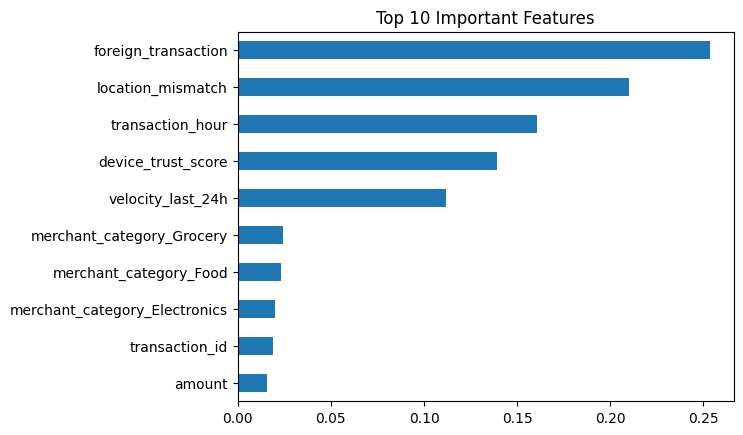

In [29]:
feature_importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [30]:
import pickle

with open("fraud_rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [32]:
THRESHOLD = 0.3

def fraud_engine(model, input_data):
    prob = model.predict_proba(input_data)[0][1]
    risk_score = round(prob * 100, 2)

    if prob >= THRESHOLD:
        decision = "FRAUD ALERT"
    else:
        decision = "Normal Transaction"

    return {
        "fraud_probability": prob,
        "risk_score": risk_score,
        "decision": decision
    }

In [24]:
from google.colab import files
files.download("fraud_model_bundle.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>